# 05 — Module 3: missing-value prediction

Predicts **whether** a value will be missing in a target column (early warning), using the other columns as features. One XGBoost classifier per target column, with class imbalance handled by `scale_pos_weight`. This is different from imputation (DataWig), which predicts what the value should be.

### The missingness mechanism matters (ties to Rubin, 1976)
- **MCAR** (missing completely at random) is, by definition, independent of the other columns, so it **cannot be predicted** — a classifier scores ~0.5. This is a correct theoretical result.
- **MAR** (missing at random) depends on other observed values (here, larger amounts are more likely to be missing), which is realistic and learnable.
We evaluate on MAR and show MCAR as a contrast.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from preprocessing import temporal_split
import module3_missing as m3
DATA_PATH = '../data/HI-Small_Trans.csv'

In [2]:
cols=['Timestamp','Amount Paid','Amount Received','Receiving Currency','Payment Currency','Payment Format']
df = pd.read_csv(DATA_PATH, usecols=cols)
ref, _ = temporal_split(df, reference_days=3, max_days=10)
train = ref.sample(80_000, random_state=42).reset_index(drop=True)
test  = ref.sample(40_000, random_state=7).reset_index(drop=True)
targets = ['Receiving Currency', 'Payment Format']
print('train:', train.shape[0], '| test:', test.shape[0], '| targets:', targets)

train: 80000 | test: 40000 | targets: ['Receiving Currency', 'Payment Format']


## MAR — the realistic, learnable case
Missingness depends on transaction amount. One XGBoost per target column.

In [3]:
res_mar = m3.run_module3(train, test, targets, mechanism='mar', rate=0.10, seed=42)
rows = [[c, v['precision'], v['recall'], v['f1'], v['roc_auc']] for c,v in res_mar.items()]
tbl = pd.DataFrame(rows, columns=['target','precision','recall','f1','roc_auc']).round(3)
avg = pd.DataFrame([['AVERAGE', np.nan, np.nan, tbl['f1'].mean(), tbl['roc_auc'].mean()]],
                   columns=tbl.columns).round(3)
pd.concat([tbl, avg], ignore_index=True)

,target,precision,recall,f1,roc_auc
0,Receiving Currency,0.183,0.795,0.298,0.764
1,Payment Format,0.184,0.790,0.299,0.765
2,AVERAGE,NaN,NaN,0.298,0.764


## MCAR — the contrast (should be ~0.5, i.e. unpredictable)

In [4]:
res_mcar = m3.run_module3(train, test, targets, mechanism='mcar', rate=0.10, seed=42)
pd.DataFrame([[c, round(v['roc_auc'],3)] for c,v in res_mcar.items()],
             columns=['target','roc_auc (MCAR)'])

,target,roc_auc (MCAR)
0,Receiving Currency,0.496
1,Payment Format,0.491


## What drives the prediction?
Feature importance for one target — the amount features should dominate, confirming the model learned the MAR pattern.

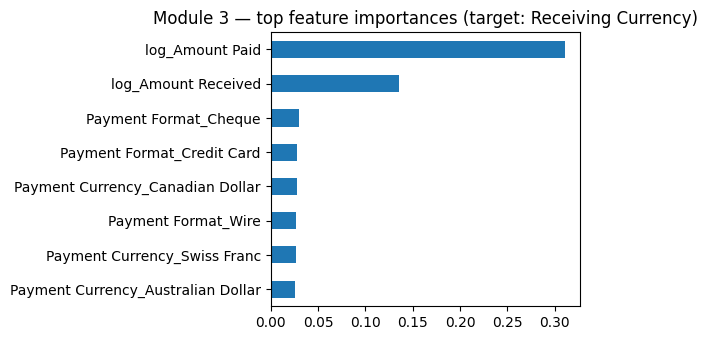

In [5]:
from module3_missing import inject_missing_values_mar, build_module3_features, train_missing_classifier
col = 'Receiving Currency'
trc, trg = inject_missing_values_mar(train, col, rate=0.10, seed=42)
Xtr = build_module3_features(trc, col)
clf = train_missing_classifier(Xtr, trg.values)
imp = pd.Series(clf.feature_importances_, index=Xtr.columns).sort_values(ascending=False).head(8)
imp.iloc[::-1].plot(kind='barh', figsize=(6,3.5))
plt.title('Module 3 — top feature importances (target: Receiving Currency)')
plt.tight_layout(); plt.savefig('../results/module3_importance.png', dpi=120); plt.show()

## Reading the results
- **MCAR ~0.5** confirms the theory: random missingness is unpredictable. This is the correct result, not a failure, and it matches Rubin (1976).
- **MAR ROC-AUC ~0.76** shows the per-column XGBoost design predicts missingness when it follows a pattern, which is the realistic pipeline case. Precision is low because missingness is rare (10%) and the signal is moderate; recall is high thanks to `scale_pos_weight`. ROC-AUC is the fairer summary.
- The feature importance confirms the amount features drive the prediction, exactly as the MAR injection intends.